In [ ]:
import re
import numpy as np
import pandas as pd

with open("study_results.csv") as file:
    lines = [line.rstrip() for line in file]

content = []

for line in lines:
    thisrow = re.split(':|,|#', line)
    if(thisrow[0] != "PID" and thisrow[0] != "2B3943EC166B4B9FACB9395A2CB44137" and thisrow[0] != "5D083AD0751E47248EAA013D74068D47" and thisrow[0] != "D14881628ECD4CF68081C0EBE1B01534" and thisrow[0] != "EAFAF2AD596A4DD5867A46EE79C3DCC2"):
        content.append(thisrow)


columns = ['PID', 'SNO', 'M', 'Variation', 'B']
for qs in range(1,20):
    columns.append("q" + str(qs))
columns.append('T')
columns.append('time')
columns.append('R')
columns.append('reverse')

df = pd.DataFrame(content, columns=columns)

df = df.drop('M', axis=1)
df = df.drop('B', axis=1)
# df = df.drop('.', axis=1)
df = df.drop('T', axis=1)
df = df.drop('R', axis=1)

for i in range(1,20):
    df["q" + str(i)] = pd.to_numeric(df['q' + str(i)])

# reverse based on left-right arrangement
df['q1'] = np.where(df.reverse !=  "1\"",df.q1, 2-df.q1)
df['q2'] = np.where(df.reverse !=  "1\"",df.q2, 2-df.q2)
df['q3'] = np.where(df.reverse !=  "1\"",df.q3, 2-df.q3)
df['q4'] = np.where(df.reverse !=  "1\"",df.q4, 2-df.q4)
df['q5'] = np.where(df.reverse !=  "1\"",df.q5, 2-df.q5)
df['q6'] = np.where(df.reverse !=  "1\"",df.q6, 2-df.q6)
df['q7'] = np.where(df.reverse !=  "1\"",df.q7, 2-df.q7)
df['q8'] = np.where(df.reverse !=  "1\"",df.q8, 2-df.q8)
df['q9'] = np.where(df.reverse !=  "1\"",df.q9, 2-df.q9)
df['q10'] = np.where(df.reverse !=  "1\"",df.q10, 2-df.q10)
df['q11'] = np.where(df.reverse !=  "1\"",df.q11, 2-df.q11)
df['q12'] = np.where(df.reverse !=  "1\"",df.q12, 2-df.q12)
df['q13'] = np.where(df.reverse !=  "1\"",df.q13, 2-df.q13)
df['q14'] = np.where(df.reverse !=  "1\"",df.q14, 2-df.q14)
df['q15'] = np.where(df.reverse !=  "1\"",df.q15, 2-df.q15)
df['q16'] = np.where(df.reverse !=  "1\"",df.q16, 2-df.q16)
df['q17'] = np.where(df.reverse !=  "1\"",df.q17, 2-df.q17)

df['Low'] = np.where(df.reverse !=  "1\"",df.q18, df.q19)
df['High'] = np.where(df.reverse !=  "1\"",df.q19, df.q18)

df = df.drop('reverse', axis=1)

df["Extraversion"] = pd.to_numeric(df['q1']) - pd.to_numeric(df['q6'])
df["Agreeableness"] = pd.to_numeric(df['q7']) - pd.to_numeric(df['q2'])
df["Conscientiousness"] = pd.to_numeric(df['q3']) - pd.to_numeric(df['q8'])
df["Emotional Stability"] = pd.to_numeric(df['q9']) - pd.to_numeric(df['q4'])
df["Openness"] = pd.to_numeric(df['q5']) - pd.to_numeric(df['q10'])

# df["Happy"] = pd.to_numeric(df['q11']) - 1
# df["Sad"] = pd.to_numeric(df['q12']) - 1
# df["Fear"] = pd.to_numeric(df['q13']) - 1
# df["Disgust"] = pd.to_numeric(df['q14']) - 1
# df["Anger"] = pd.to_numeric(df['q15']) - 1
# df["Surprise"] = pd.to_numeric(df['q16']) - 1
# df["Realism"] = pd.to_numeric(df['q17']) - 1

df["Variation"] = df["Variation"].map({'0': 'walk', '1': 'wave', '2':'sit','3':'put'})
df['Variation'] = pd.Categorical(df['Variation'], ['walk','wave','sit','put'])

df["SNO"] = df["SNO"].map({'1': 'Weight', '2': 'Time', '3':'Space','4':'Flow'})
df['SNO'] = pd.Categorical(df['SNO'], ['Weight','Space','Time','Flow'])

# remove duplicates
df = df.drop_duplicates(subset=['PID', 'SNO', 'Variation'])

values, counts = np.unique(df["PID"].to_numpy(), return_counts=True)
for i, val in enumerate(counts):
  if val != 16:
    print(str(values[i]) + " " + str(val))

# make groups
groups = [
    df.loc[df["SNO"] == "Weight"], # weight
     df.loc[df["SNO"] == "Space"], # space
    df.loc[df["SNO"] == "Time"], # time
    df.loc[df["SNO"] == "Flow"] # flow
]

group_names =  ["Weight","Space","Time","Flow"]
meas = ["Extraversion","Agreeableness*","Conscientiousness","Emotional Stability*","Openness","Extraversion*","Agreeableness","Conscientiousness*","Emotional Stability","Openness*","Happiness","Sadness","Fear","Disgust","Anger","Surprise","Human Likeness"]

display(df)

,PID,SNO,Variation,q1,q2,q3,q4,q5,q6,q7,...,q18,q19,time,Low,High,Extraversion,Agreeableness,Conscientiousness,Emotional Stability,Openness
0,yakupp1994@outlook.com,Weight,sit,0,1,0,2,0,2,2,...,4,5,72.87,5,4,-2,1,-2,-2,-1
1,yakupp1994@outlook.com,Flow,wave,0,2,0,2,0,0,0,...,4,5,71.33,5,4,0,-2,-2,-2,-2
2,yakupp1994@outlook.com,Time,put,2,0,2,0,2,0,2,...,5,5,88.65,5,5,2,2,2,2,1
3,yakupp1994@outlook.com,Flow,walk,2,2,0,0,0,0,0,...,5,5,54.67,5,5,2,-2,-2,0,-2
4,yakupp1994@outlook.com,Time,wave,2,2,2,0,1,0,0,...,5,5,77.94,5,5,2,-2,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,54F6CA3CBEDE42E2A4B39F4185667BCF,Weight,put,0,1,2,0,0,2,1,...,2,3,59.68,2,3,-2,0,2,2,-2
517,54F6CA3CBEDE42E2A4B39F4185667BCF,Time,put,2,0,2,0,2,0,2,...,3,2,50.99,2,3,2,2,1,0,2
518,54F6CA3CBEDE42E2A4B39F4185667BCF,Space,walk,2,1,2,0,2,0,2,...,2,3,49.23,2,3,2,1,2,2,1
519,54F6CA3CBEDE42E2A4B39F4185667BCF,Flow,wave,0,1,0,1,0,2,0,...,1,3,59.42,3,1,-2,-1,-2,-1,0


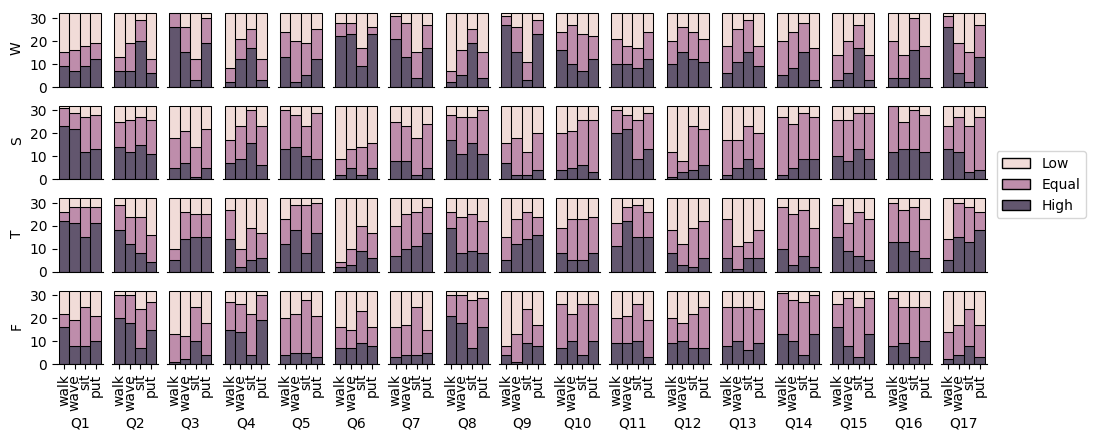

In [ ]:
# alternative with human likeness scores
import seaborn as sns
import matplotlib.pyplot as plt

grs = ["W","S","T","F"]

fig, axis = plt.subplots(4, 17, figsize=(12,4.6))
for i in range(17):
  for j in range(4):
    sns.histplot(data=groups[j], x="Variation", hue="q" + str(i+1), multiple="stack",ax=axis[j][i])

    if i == 0 and j == 0:
      legend = axis[i][j].get_legend()
      handles = legend.legend_handles
      fig.legend(handles, ["Low","Equal","High"], loc='center right', bbox_to_anchor=(0.988,0.5))

    if i != 0:
      axis[j][i].get_yaxis().set_visible(False)
    else:
      axis[j][i].get_yaxis().set_label_text(grs[j])

    axis[j][i].get_legend().remove()
    axis[j][i].spines['top'].set_visible(False)
    axis[j][i].spines['right'].set_visible(False)
    #axis[j][i].spines['bottom'].set_visible(False)
    axis[j][i].spines['left'].set_visible(False)

    #axis[j][i].get_xaxis().set_ticks([])
    axis[j][i].tick_params(axis='x', labelrotation=90)
    #axis[j][i].get_yaxis().set_ticks([])
    axis[j][i].set_yticks([0,10,20,30])

    if j == 3:
      axis[j][i].get_xaxis().set_label_text("Q" + str(i+1)) # axis[j][i].set_title("Q" + str(i+1), pad=-14, y=-0.01)
    else:
      axis[j][i].get_xaxis().set_visible(False)

plt.savefig("all.pdf", transparent=True, dpi=400, bbox_inches='tight')

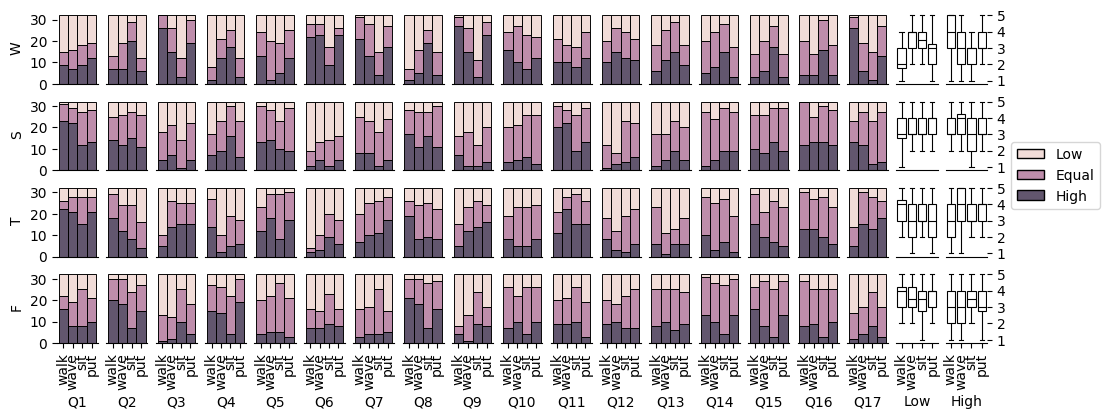

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

grs = ["W","S","T","F"]

fig, axis = plt.subplots(4, 19, figsize=(12,4.3))
for i in range(19):
  for j in range(4):
    if i == 17:
      sns.boxplot(data=groups[j], x="Variation", y="Low", flierprops={"marker": ""}, color="1.", linecolor="#000", linewidth=.8, ax=axis[j][i])
    elif i == 18:
      sns.boxplot(data=groups[j], x="Variation", y="High", flierprops={"marker": ""}, color="1.", linecolor="#000", linewidth=.8, ax=axis[j][i])
    else:
      sns.histplot(data=groups[j], x="Variation", hue="q" + str(i+1), multiple="stack",ax=axis[j][i])

    if i == 0 and j == 0:
      legend = axis[i][j].get_legend()
      handles = legend.legend_handles
      fig.legend(handles, ["Low","Equal","High"], loc='center right', bbox_to_anchor=(1.,0.5))

    if i != 0:
      axis[j][i].get_yaxis().set_visible(False)
    else:
      axis[j][i].get_yaxis().set_label_text(grs[j])

    if i < 17:
      axis[j][i].get_legend().remove()
    axis[j][i].spines['top'].set_visible(False)
    axis[j][i].spines['right'].set_visible(False)
    #axis[j][i].spines['bottom'].set_visible(False)
    axis[j][i].spines['left'].set_visible(False)

    #axis[j][i].get_xaxis().set_ticks([])
    axis[j][i].tick_params(axis='x', labelrotation=90)
    #axis[j][i].get_yaxis().set_ticks([])

    if i < 17:
      axis[j][i].set_yticks([0,10,20,30])

    if i == 18:
      axis[j][i].get_yaxis().set_visible(True)
      axis[j][i].get_yaxis().tick_right()
      axis[j][i].set_yticks([1,2,3,4,5])
      axis[j][i].get_yaxis().set_label_text("")


    if j == 3:
      if i < 17:
        axis[j][i].get_xaxis().set_label_text("Q" + str(i+1)) # axis[j][i].set_title("Q" + str(i+1), pad=-14, y=-0.01)
      elif i == 17:
        axis[j][i].get_xaxis().set_label_text("Low")
      else:
        axis[j][i].get_xaxis().set_label_text("High")
    else:
      axis[j][i].get_xaxis().set_visible(False)

plt.savefig("all.pdf", transparent=True, dpi=400, bbox_inches='tight')

In [ ]:
ddo = axis[j][i].get_yaxis()

In [ ]:
ddo.set_label_text

AttributeError: 'str' object has no attribute 'set_text'

In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.3 MB/s eta 0:00:00


In [ ]:
import pingouin as pg

group_names =  ["Weight","Space","Time","Flow"]

iccs = np.zeros((4,17),dtype='object')
iccs_f = np.zeros((4,17))
iccs_ps = np.zeros((4,17),dtype='object')

iccs_str = np.zeros((4,17),dtype='object')

for i, gn in enumerate(group_names):
  ft = df.loc[df["SNO"] == gn]
  for j in range(17):
    results = pg.intraclass_corr(data=ft, targets='Variation', raters='PID', ratings='q'+str(j+1))

    icc_f = results['ICC'][5]
    pv_f = results['pval'][5]
    icc = "{:.3f}".format(results['ICC'][5])

    if icc_f < 0:
      icc = "{:.3f}".format(abs(results['ICC'][5]))
      if icc == "0.000":
          icc = "-.001"
      elif icc == "1.000":
          icc = "-.999"
      else:
          icc = "-" + icc[1:]
    else:
      if icc == "0.000":
          icc = ".001"
      elif icc == "1.000":
          icc = ".999"
      else:
          icc = icc[1:]

    if pv_f <= 0.05:
      if abs(icc_f) >= 0.75:
        icc = "\\cellcolor[HTML]{636363}{\\color{white}" + str(icc) + "}"
      else:
        icc = "\\cellcolor[HTML]{D3D3D3}" + str(icc)

    iccs[i,j] = icc
    iccs_f[i,j] = icc_f

    pv = "{:.3f}".format(results['pval'][5])
    if pv == "0.000":
        pv = ".001"
    elif pv == "1.000":
        pv = ".999"
    else:
        pv = pv[1:]

    if pv_f <= 0.05:
      if abs(icc_f) >= 0.75:
        pv = "\\cellcolor[HTML]{636363}{\\color{white}" + str(pv) + "}"
      else:
        pv = "\\cellcolor[HTML]{D3D3D3}" + str(pv)

    iccs_ps[i,j] = pv
    iccs_str[i,j] = str(icc) + " & " + str(pv)

for i in range(1,18):
    for j in range(4):
        if j == 0:
          print("\\textbf{Q" + str(i) + "} & " + iccs_str[j][i-1] + " & ", end =" ")
        elif j != 3:
            print(iccs_str[j][i-1] + " & ", end =" ")
        else:
            print(iccs_str[j][i-1] + "", end =" ")
    print("\\\\")

\textbf{Q1} & -.733 & .631 &  \cellcolor[HTML]{636363}{\color{white}.840} & \cellcolor[HTML]{636363}{\color{white}.001} &  -.251 & .722 &  .025 & .385 \\
\textbf{Q2} & \cellcolor[HTML]{636363}{\color{white}.906} & \cellcolor[HTML]{636363}{\color{white}.001} &  -.065 & .806 &  \cellcolor[HTML]{636363}{\color{white}.894} & \cellcolor[HTML]{636363}{\color{white}.001} &  \cellcolor[HTML]{636363}{\color{white}.783} & \cellcolor[HTML]{636363}{\color{white}.005} \\
\textbf{Q3} & \cellcolor[HTML]{636363}{\color{white}.961} & \cellcolor[HTML]{636363}{\color{white}.001} &  \cellcolor[HTML]{D3D3D3}.660 & \cellcolor[HTML]{D3D3D3}.037 &  \cellcolor[HTML]{636363}{\color{white}.889} & \cellcolor[HTML]{636363}{\color{white}.001} &  \cellcolor[HTML]{636363}{\color{white}.870} & \cellcolor[HTML]{636363}{\color{white}.001} \\
\textbf{Q4} & \cellcolor[HTML]{636363}{\color{white}.920} & \cellcolor[HTML]{636363}{\color{white}.001} &  \cellcolor[HTML]{636363}{\color{white}.857} & \cellcolor[HTML]{636363}{\co

In [ ]:
import scipy.stats as stats
import numpy as np

from scipy import stats

c1 = 0
c2 = 0
c3 = 0

qps = np.empty((4,17),dtype='object')
qns = np.zeros((4,17))
mns = np.zeros((4,17),dtype='object')

for j in range(4):
    inqps = []
    for i in range(1,18):
        # fdfilt = groups[j] # groups[j].loc[groups[j]["Variation"] == "put"] # groups[j]["q" + str(i)]
        fdfilt = groups[j] # groups[j][groups[j]["Variation"] == fillltrd]
        arr = fdfilt["q" + str(i)].to_numpy()

        comp_dist = []
        for k in range(int(arr.shape[0]/3)):
            comp_dist.append(0)
            comp_dist.append(1)
            comp_dist.append(2)
        result =stats.ttest_ind(a=arr, b=comp_dist, equal_var=True)
        p = result.pvalue

        if p < 0.05:
            c1 += 1
        mns[j][i-1] = "{:.2f}".format(arr.mean()-1)

        inqps.append(p)
    # print(inqps)
    outqps = stats.false_discovery_control(inqps)
    # print(outqps)

    for i in range(1,18):
        icc_f = iccs_f[j][i-1]
        p = outqps[i-1]

        if icc_f >= 0.4:
          ps = "{:.3f}".format(p)
          if ps == "0.000":
              ps = ".001"
          elif ps == "1.000":
              ps = ".999"
          else:
              ps = ps[1:]

          if p < 0.05:
              qps[j][i-1] = "\\cellcolor[HTML]{636363}{\\color{white}" + str(mns[j][i-1]) + "} & "
              qps[j][i-1] += "\\cellcolor[HTML]{636363}{\\color{white}" + str(ps) + "}"
              # ps += "*"
              c2 += 1
          elif inqps[i-1] < 0.05:
              qps[j][i-1] = "\\cellcolor[HTML]{D3D3D3}" + str(mns[j][i-1]) + " & "
              qps[j][i-1] += "\\cellcolor[HTML]{D3D3D3}" + str(ps)
              # ps += "!"
          else:
              qps[j][i-1] = str(mns[j][i-1]) + " & "
              qps[j][i-1] += str(ps)
          qns[j][i-1] = p
        else:
          qps[j][i-1] = "--- & ---"
          c3 += 1
        # print(ps)
    # print()


for i in range(1,18):
    for j in range(4):
        if j == 0:
          print("\\textbf{Q" + str(i) + "} & " + qps[j][i-1] + " & ", end =" ")
        elif j != 3:
            print(qps[j][i-1] + " & ", end =" ")
        else:
            print(qps[j][i-1] + "", end =" ")
    print("\\\\")

\textbf{Q1} & --- & --- &  \cellcolor[HTML]{636363}{\color{white}0.45} & \cellcolor[HTML]{636363}{\color{white}.001} &  --- & --- &  --- & --- \\
\textbf{Q2} & -0.12 & .453 &  --- & --- &  0.05 & .601 &  \cellcolor[HTML]{636363}{\color{white}0.34} & \cellcolor[HTML]{636363}{\color{white}.003} \\
\textbf{Q3} & \cellcolor[HTML]{636363}{\color{white}0.27} & \cellcolor[HTML]{636363}{\color{white}.036} &  \cellcolor[HTML]{636363}{\color{white}-0.27} & \cellcolor[HTML]{636363}{\color{white}.010} &  0.05 & .601 &  \cellcolor[HTML]{636363}{\color{white}-0.34} & \cellcolor[HTML]{636363}{\color{white}.003} \\
\textbf{Q4} & \cellcolor[HTML]{D3D3D3}-0.22 & \cellcolor[HTML]{D3D3D3}.104 &  0.02 & .813 &  \cellcolor[HTML]{D3D3D3}-0.22 & \cellcolor[HTML]{D3D3D3}.072 &  \cellcolor[HTML]{636363}{\color{white}0.23} & \cellcolor[HTML]{636363}{\color{white}.045} \\
\textbf{Q5} & -0.06 & .581 &  \cellcolor[HTML]{636363}{\color{white}0.22} & \cellcolor[HTML]{636363}{\color{white}.036} &  \cellcolor[HTML]{636

In [ ]:
!pip install plot_likert

/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)
/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)
/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)
/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)


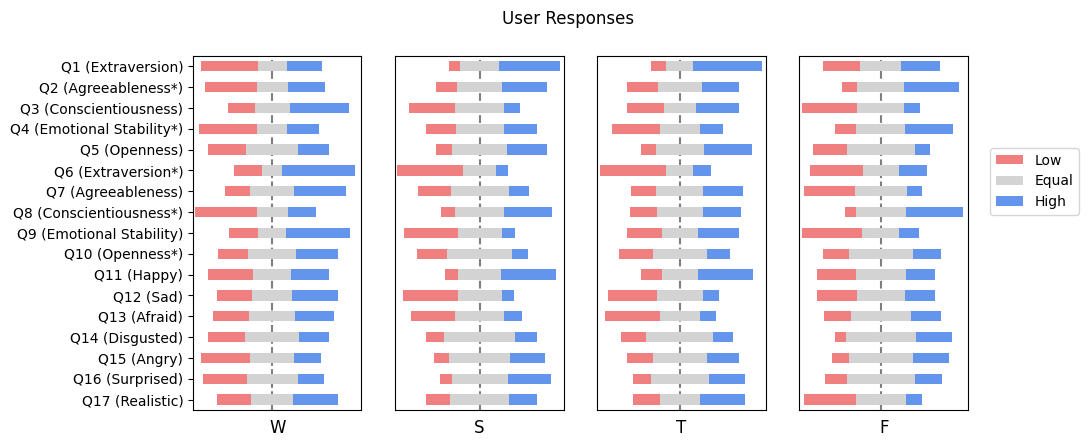

In [ ]:
import plot_likert
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

fig, axis = plt.subplots(1, 4, figsize=(10,4.6))

#fig = plt.figure(layout="constrained",figsize=(5,4)) # plt.subplots(1, 5, figsize=(4,3))
fig.suptitle("User Responses")

dict_likert = {
    0:"Low",
    1:"Equal",
    2:"High"
}

likert = ["Low","Equal","High"]
grs = ["W","S","T","F"]

def get_map_ind(i):
    return fdfilt["q" + str(i)].map(dict_likert)


dfp_map = {"q1":'Q1 (Extraversion)', "q2":'Q2 (Agreeableness*)', "q3":'Q3 (Conscientiousness)', "q4":'Q4 (Emotional Stability*)', "q5":'Q5 (Openness)',"q6":'Q6 (Extraversion*)', "q7":'Q7 (Agreeableness)', "q8":'Q8 (Conscientiousness*)', "q9":'Q9 (Emotional Stability)', "q10":'Q10 (Openness*)', "q11":'Q11 (Happy)',"q12":'Q12 (Sad)',"q13":'Q13 (Afraid)',"q14":'Q14 (Disgusted)',"q15":'Q15 (Angry)', "q16":'Q16 (Surprised)', "q17":'Q17 (Realistic)'}

for gg in range(4):
  fdfilt = groups[gg]

  dfp = []
  for i in range(17):
      dfp.append(get_map_ind(i+1))
      # dfp_map[str(i+1)] = "Q" + str(i+1)

  dfp = pd.concat(dfp, axis=1)
  dfp = dfp.rename(columns=dfp_map)

  plot_likert.plot_likert(dfp, likert,  colors=['#ffffff00', 'lightcoral', 'lightgray', 'cornflowerblue'], plot_percentage=False,ax=axis[gg])

  axis[gg].set_title(grs[gg], pad=-14, y=-0.01)
  if gg != 0:
    axis[gg].get_yaxis().set_visible(False)
  axis[gg].get_legend().remove()
  axis[gg].get_xaxis().set_visible(False)

h, l = axis[0].get_legend_handles_labels()
plt.legend(h, l,  loc='upper right',bbox_to_anchor=(1.7,0.76))

plt.savefig("likert_self.pdf", transparent=True, dpi=400, bbox_inches='tight')

In [ ]:
# ANOVA
import scipy.stats as stats
import numpy as np

from scipy import stats
from scipy.stats import f_oneway

c1 = 0
c2 = 0

qps = np.empty((4,4,17),dtype='object')
qns = np.zeros((4,4,17))

anvs = np.zeros((4,17))


filvars = ['walk','wave','sit','put']
oceans = ['Extraversion','Agreeableness','Conscientiousness','Emotional Stability','Openness']

for fin, fillltrd in enumerate(filvars):
    for j in range(4):
        inqps = []
        for i in range(1,18):
            fdfilt = groups[j][groups[j]["Variation"] == fillltrd]
            arr = fdfilt["q" + str(i)].to_numpy()

            comp_dist = []
            for k in range(int(arr.shape[0]/3)):
                comp_dist.append(0)
                comp_dist.append(1)
                comp_dist.append(2)
            result =stats.ttest_ind(a=arr, b=comp_dist, equal_var=True)
            p = result.pvalue

            if p < 0.05:
                c1 += 1

            inqps.append(p)
        # print(inqps)
        outqps = stats.false_discovery_control(inqps)
        # print(outqps)

        for i in range(1,18):
            p = outqps[i-1]

            ps = "{:.3f}".format(p)
            if ps == "0.000":
                ps = ".001"
            elif ps == "1.000":
                ps = ".999"
            else:
                ps = ps[1:]

            if p < 0.05:
                qps[fin][j][i-1] = "\\cellcolor[HTML]{5ce65c}" + str(ps)
                # ps += "*"
                c2 += 1
            elif inqps[i-1] < 0.05:
                qps[fin][j][i-1] = "\\cellcolor[HTML]{D3D3D3}" + str(ps)
                # ps += "!"
            else:
                qps[fin][j][i-1] = ps
            qns[fin][j][i-1] = p

            # print(ps)
        # print()

for quesno in range(17):
    for j in range(4):
        g0 = groups[j][groups[j]["Variation"] == filvars[0]]["q" + str(quesno+1)].to_numpy()
        g1 = groups[j][groups[j]["Variation"] == filvars[1]]["q" + str(quesno+1)].to_numpy()
        g2 = groups[j][groups[j]["Variation"] == filvars[2]]["q" + str(quesno+1)].to_numpy()
        g3 = groups[j][groups[j]["Variation"] == filvars[3]]["q" + str(quesno+1)].to_numpy()

        mm = [g0.mean()-1.0,g1.mean()-1.0,g2.mean()-1.0,g3.mean()-1.0]

        f_statistic, p_value = f_oneway(g0, g1, g2, g3)
        anvs[j,quesno] = p_value

        if p_value < 0.05 and iccs_f[j][quesno] >= 0.4:
            isshown = False
            sigvals_part = [0,0,0,0]
            sigline = ""

            for anivar in range(4):
              ppart = groups[j][groups[j]["Variation"] == filvars[anivar]]["q" + str(quesno+1)].to_numpy()

              numsize = ppart.size
              comp_dist = []
              for k in range(int(numsize/3)):
                  comp_dist.append(0)
                  comp_dist.append(1)
                  comp_dist.append(2)
              result =stats.ttest_ind(a=ppart, b=comp_dist, equal_var=True)
              sigvals_part[anivar] = result.pvalue

              if result.pvalue < 0.05:
                sigline += " & " + "\\cellcolor[HTML]{D3D3D3}" + "{:.2f}".format(mm[anivar])
                isshown = True
              else:
                sigline += " & " + "{:.2f}".format(mm[anivar])

            if isshown:
              ps = "{:.3f}".format(p_value)
              if ps == "0.000":
                  ps = ".001"
              elif ps == "1.000":
                  ps = ".999"
              else:
                  ps = ps[1:]
              print("\\textbf{Q" + str(quesno+1) + "-" + group_names[j][0] + "} & " + "{:.3f}".format(f_statistic) + " & " + ps + sigline + " \\\\ \\hline", end =" ")
              print("")


# for i in range(5):
#     for j in range(4):
#         for fin in range(4):
#             if j == 0:
#               print("\\textbf{" + oceans[i] + "}& " + qps[j][i-1] + " & ", end =" ")
#             elif j != 3:
#                 print(qps[fin][j][i] + " & ", end =" ")
#             else:
#                 print(qps[fin][j][i] + "", end =" ")
#     print("\\\\")

# print(c1)
# print(c2)

\textbf{Q1-S} & 4.002 & .009 & \cellcolor[HTML]{D3D3D3}0.69 & \cellcolor[HTML]{D3D3D3}0.59 & 0.22 & 0.28 \\ \hline 
\textbf{Q2-W} & 10.594 & .001 & -0.38 & -0.19 & \cellcolor[HTML]{D3D3D3}0.53 & \cellcolor[HTML]{D3D3D3}-0.44 \\ \hline 
\textbf{Q2-T} & 7.411 & .001 & \cellcolor[HTML]{D3D3D3}0.47 & 0.12 & 0.00 & -0.38 \\ \hline 
\textbf{Q2-F} & 5.071 & .002 & \cellcolor[HTML]{D3D3D3}0.56 & \cellcolor[HTML]{D3D3D3}0.50 & -0.03 & 0.31 \\ \hline 
\textbf{Q3-W} & 26.964 & .001 & \cellcolor[HTML]{D3D3D3}0.81 & 0.28 & \cellcolor[HTML]{D3D3D3}-0.53 & \cellcolor[HTML]{D3D3D3}0.53 \\ \hline 
\textbf{Q3-T} & 7.970 & .001 & \cellcolor[HTML]{D3D3D3}-0.53 & 0.25 & 0.25 & 0.25 \\ \hline 
\textbf{Q3-F} & 7.137 & .001 & \cellcolor[HTML]{D3D3D3}-0.56 & \cellcolor[HTML]{D3D3D3}-0.56 & 0.09 & -0.31 \\ \hline 
\textbf{Q4-W} & 12.750 & .001 & \cellcolor[HTML]{D3D3D3}-0.69 & 0.03 & 0.31 & \cellcolor[HTML]{D3D3D3}-0.53 \\ \hline 
\textbf{Q4-S} & 5.334 & .002 & -0.25 & 0.00 & \cellcolor[HTML]{D3D3D3}0.44 & -0.0

In [ ]:
# correlation
import scipy.stats
import numpy as np

cor_limit = 0.6
ddc = [{},{},{},{},{}]
alls = {}

for g in range(4):
    grp = groups[g]
    print(group_names[g])
    for i in range(1,18):
        for j in range(i,18):
            if i != j:
                if not(j - i == 5 and i <=5):
                    ar1 = grp["q" + str(i)].to_numpy()
                    ar2 = grp["q" + str(j)].to_numpy()
                    cor, pval = scipy.stats.pearsonr(ar1, ar2)
                    if abs(cor) >= cor_limit:
                        ddc[g]["q" + str(i) + "-" + "q" + str(j)] = "{:.3f}".format(cor)
                        alls["q" + str(i) + "-" + "q" + str(j)] = "{:.3f}".format(cor)
                        print(str(pval) + " - " + "{:.3f}".format(cor) + " - " + "q" + str(i) + "-" + "q" + str(j))

print("all")
for i in range(1,18):
    for j in range(i,18):
        if i != j:
            if not(j - i == 5 and i <=5):
                ar1 = df["q" + str(i)].to_numpy()
                ar2 = df["q" + str(j)].to_numpy()
                cor, pval = scipy.stats.pearsonr(ar1, ar2)
                if abs(cor) >= cor_limit:
                    ddc[4]["q" + str(i) + "-" + "q" + str(j)] = "{:.3f}".format(cor)
                    alls["q" + str(i) + "-" + "q" + str(j)] = "{:.3f}".format(cor)
                    print(str(pval) + " - " + "{:.3f}".format(cor) + " - " + "q" + str(i) + "-" + "q" + str(j))

Weight
3.7928273048718425e-14 - 0.605 - q1-q11
3.7985866751539e-15 - -0.624 - q3-q4
9.770012111138636e-18 - 0.666 - q3-q7
1.2731432690434157e-20 - 0.706 - q3-q9
7.518151089935016e-16 - -0.636 - q7-q15
5.729671910008705e-15 - -0.620 - q8-q9
9.241445401312117e-31 - -0.808 - q11-q12
Space
9.46926219158721e-16 - -0.634 - q8-q9
6.148963675746671e-34 - -0.831 - q11-q12
Time
7.9303346134519e-21 - -0.709 - q11-q12
Flow
1.9995383767252015e-14 - 0.610 - q3-q9
2.8879275023460106e-20 - -0.702 - q8-q9
3.2439898772079037e-25 - -0.759 - q11-q12
5.842251363823976e-15 - 0.620 - q12-q13
all
2.2108261433924303e-60 - 0.640 - q3-q9
4.1484931885231976e-63 - -0.651 - q8-q9
1.7202604203644144e-108 - -0.786 - q11-q12


In [ ]:
for k in alls:
    print("\\textbf{" + k.upper() + "} & ", end = "")
    for i in range(5):
        if k in ddc[i]:
            print(ddc[i][k], end = "")
        else:
            print("---", end = "")
        if i != 4:
            print(" & ", end = "")
        else:
            print(" \\\\")

\textbf{Q1-Q11} & 0.605 & --- & --- & --- & --- \\
\textbf{Q3-Q4} & -0.624 & --- & --- & --- & --- \\
\textbf{Q3-Q7} & 0.666 & --- & --- & --- & --- \\
\textbf{Q3-Q9} & 0.706 & --- & --- & 0.610 & 0.640 \\
\textbf{Q7-Q15} & -0.636 & --- & --- & --- & --- \\
\textbf{Q8-Q9} & -0.620 & -0.634 & --- & -0.702 & -0.651 \\
\textbf{Q11-Q12} & -0.808 & -0.831 & -0.709 & -0.759 & -0.786 \\
\textbf{Q12-Q13} & --- & --- & --- & 0.620 & --- \\
